In [1]:
!pip install libpysal spreg seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [spreg]32m2/3 [spreg]al]


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import libpysal
from shapely import wkt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import seaborn as sns
from spreg import GM_Lag, OLS
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

1. Dependency between built-up area and LST amplitude in Berlin

Step 1: Loading Data...
Data ready: 17049 samples.
Step 2: Training Models...

--- Model Comparison Table ---
                     Model  R-Squared      RMSE
0  Linear Regression (OLS)   0.003747  3.242095
1     Spatial Lag (GM-Lag)   0.930948  1.882707
2            Random Forest   0.956773  0.675333

Step 4: Visualizing Results...


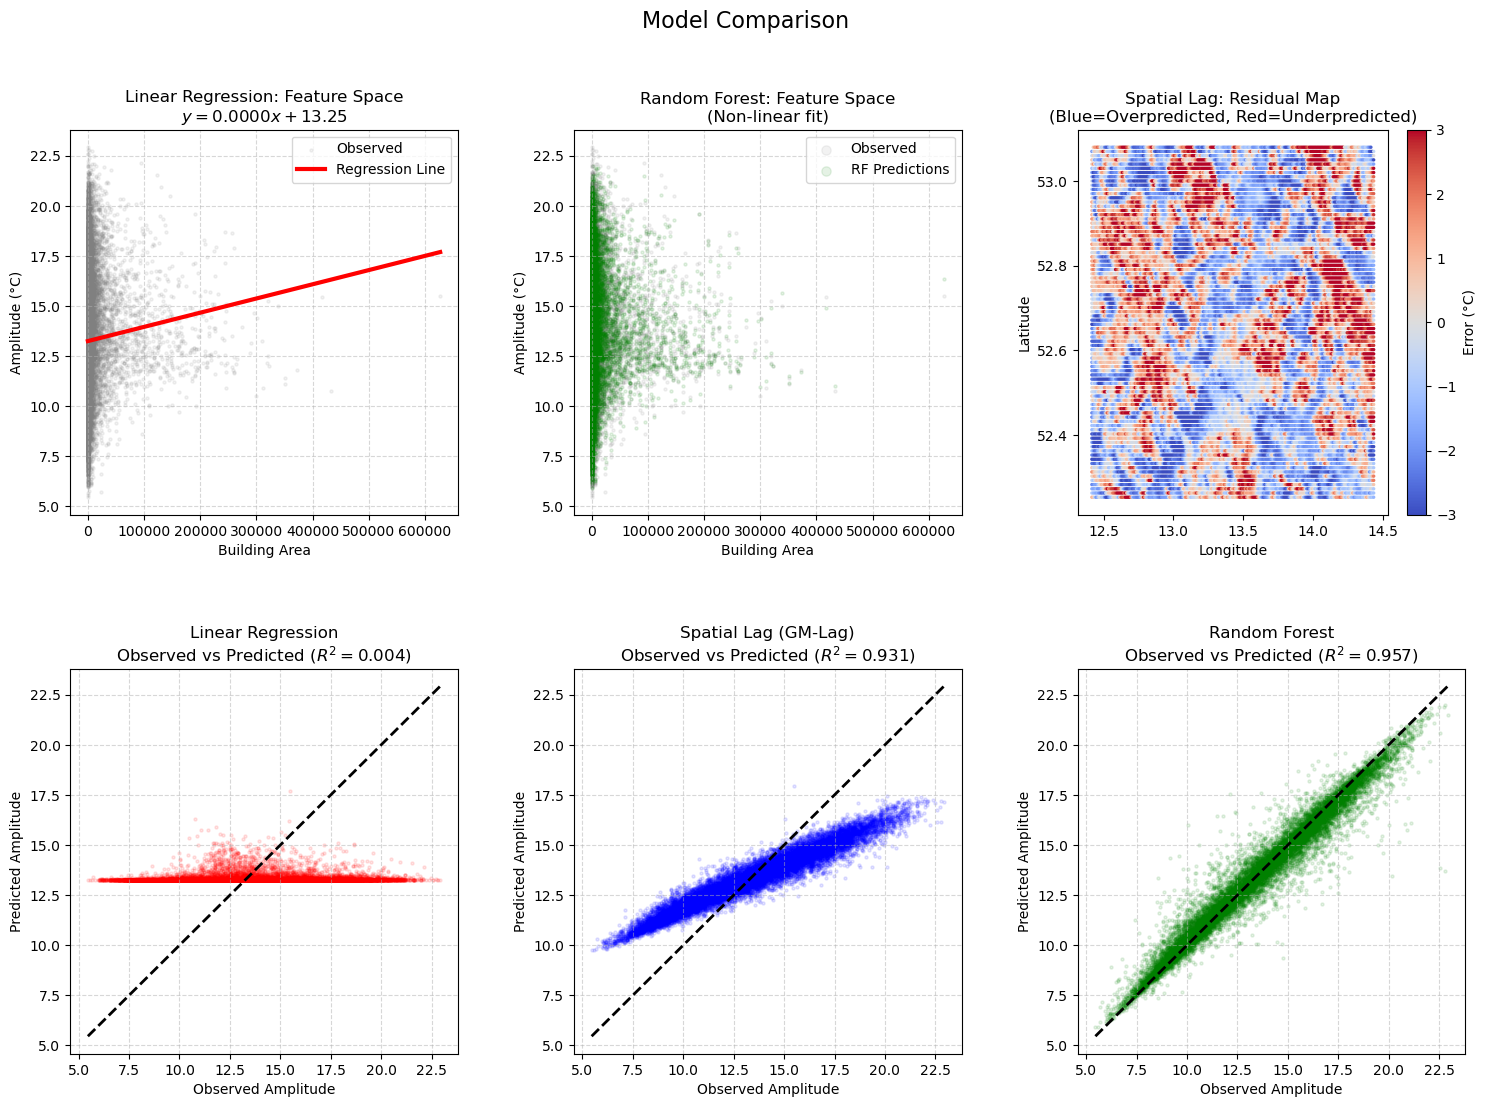

In [3]:
print("Step 1: Loading Data...")
file_path = "data/berlin_final_data.csv"
df = pd.read_csv(file_path)

df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

target = 'amplitude'
features = ['building_area']

gdf = gdf.dropna(subset=[target] + features)
gdf = gdf[gdf[target] > 0]

y = gdf[target].values.reshape(-1, 1)
X = gdf[features].values
print(f"Data ready: {len(gdf)} samples.")

print("Step 2: Training Models...")
ols = OLS(y, X, name_y=target, name_x=features)
ols_pred = ols.predy.flatten()
intercept = ols.betas[0][0]
slope = ols.betas[1][0]

w = libpysal.weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r'
gm_lag = GM_Lag(y, X, w=w, w_lags=1, name_y=target, name_x=features)
lag_pred = gm_lag.predy.flatten()

X_rf = gdf[features + ['lat', 'lon']].values
y_rf = gdf[target].values
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_full = rf.predict(X_rf)
rf_r2 = r2_score(y_rf, rf_pred_full)

print("\n--- Model Comparison Table ---")
results = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Spatial Lag (GM-Lag)', 'Random Forest'],
    'R-Squared': [ols.r2, gm_lag.pr2, rf_r2],
    'RMSE': [
        np.sqrt(mean_squared_error(y, ols_pred)),
        np.sqrt(mean_squared_error(y, lag_pred)),
        np.sqrt(mean_squared_error(y, rf_pred_full))
    ]
})
print(results)

print("\nStep 4: Visualizing Results...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1 = plt.subplot(2, 3, 1)
ax1.scatter(gdf['building_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
x_vals = np.linspace(gdf['building_area'].min(), gdf['building_area'].max(), 100)
y_vals = intercept + slope * x_vals
ax1.plot(x_vals, y_vals, color='red', linewidth=3, label='Regression Line')
ax1.set_title(f'Linear Regression: Feature Space\n$y={slope:.4f}x + {intercept:.2f}$', fontsize=12)
ax1.set_xlabel('Building Area')
ax1.set_ylabel('Amplitude (°C)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = plt.subplot(2, 3, 2)
ax2.scatter(gdf['building_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
ax2.scatter(gdf['building_area'], rf_pred_full, alpha=0.1, s=5, color='green', label='RF Predictions')
ax2.set_title(f'Random Forest: Feature Space\n(Non-linear fit)', fontsize=12)
ax2.set_xlabel('Building Area')
ax2.set_ylabel('Amplitude (°C)')
ax2.legend(markerscale=3)
ax2.grid(True, linestyle='--', alpha=0.5)

ax3 = plt.subplot(2, 3, 3)
residuals = y.flatten() - lag_pred
sc = ax3.scatter(gdf['lon'], gdf['lat'], c=residuals, cmap='coolwarm', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax3, label='Error (°C)')
ax3.set_title('Spatial Lag: Residual Map\n(Blue=Overpredicted, Red=Underpredicted)', fontsize=12)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

def plot_obs_vs_pred(ax, y_true, y_pred, title, r2, color):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    ax.set_title(f'{title}\nObserved vs Predicted ($R^2={r2:.3f}$)', fontsize=12)
    ax.set_xlabel('Observed Amplitude')
    ax.set_ylabel('Predicted Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

ax4 = plt.subplot(2, 3, 4)
plot_obs_vs_pred(ax4, y.flatten(), ols_pred, "Linear Regression", ols.r2, 'red')

ax5 = plt.subplot(2, 3, 5)
plot_obs_vs_pred(ax5, y.flatten(), lag_pred, "Spatial Lag (GM-Lag)", gm_lag.pr2, 'blue')

ax6 = plt.subplot(2, 3, 6)
plot_obs_vs_pred(ax6, y.flatten(), rf_pred_full, "Random Forest", rf_r2, 'green')

plt.suptitle('Model Comparison', fontsize=16)
plt.savefig('illustrations/model_comparison_full_built_Berlin.png', dpi=300)
plt.show()

2. Dependency between vegetation area and LST amplitude in Berlin

Step 1: Loading Data...
Data ready: 17049 samples.
Step 2: Training Models...

--- Model Comparison Table ---
                     Model  R-Squared      RMSE
0  Linear Regression (OLS)   0.216636  2.874900
1     Spatial Lag (GM-Lag)   0.933155  0.936401
2            Random Forest   0.927843  0.872532

Step 4: Visualizing Results...


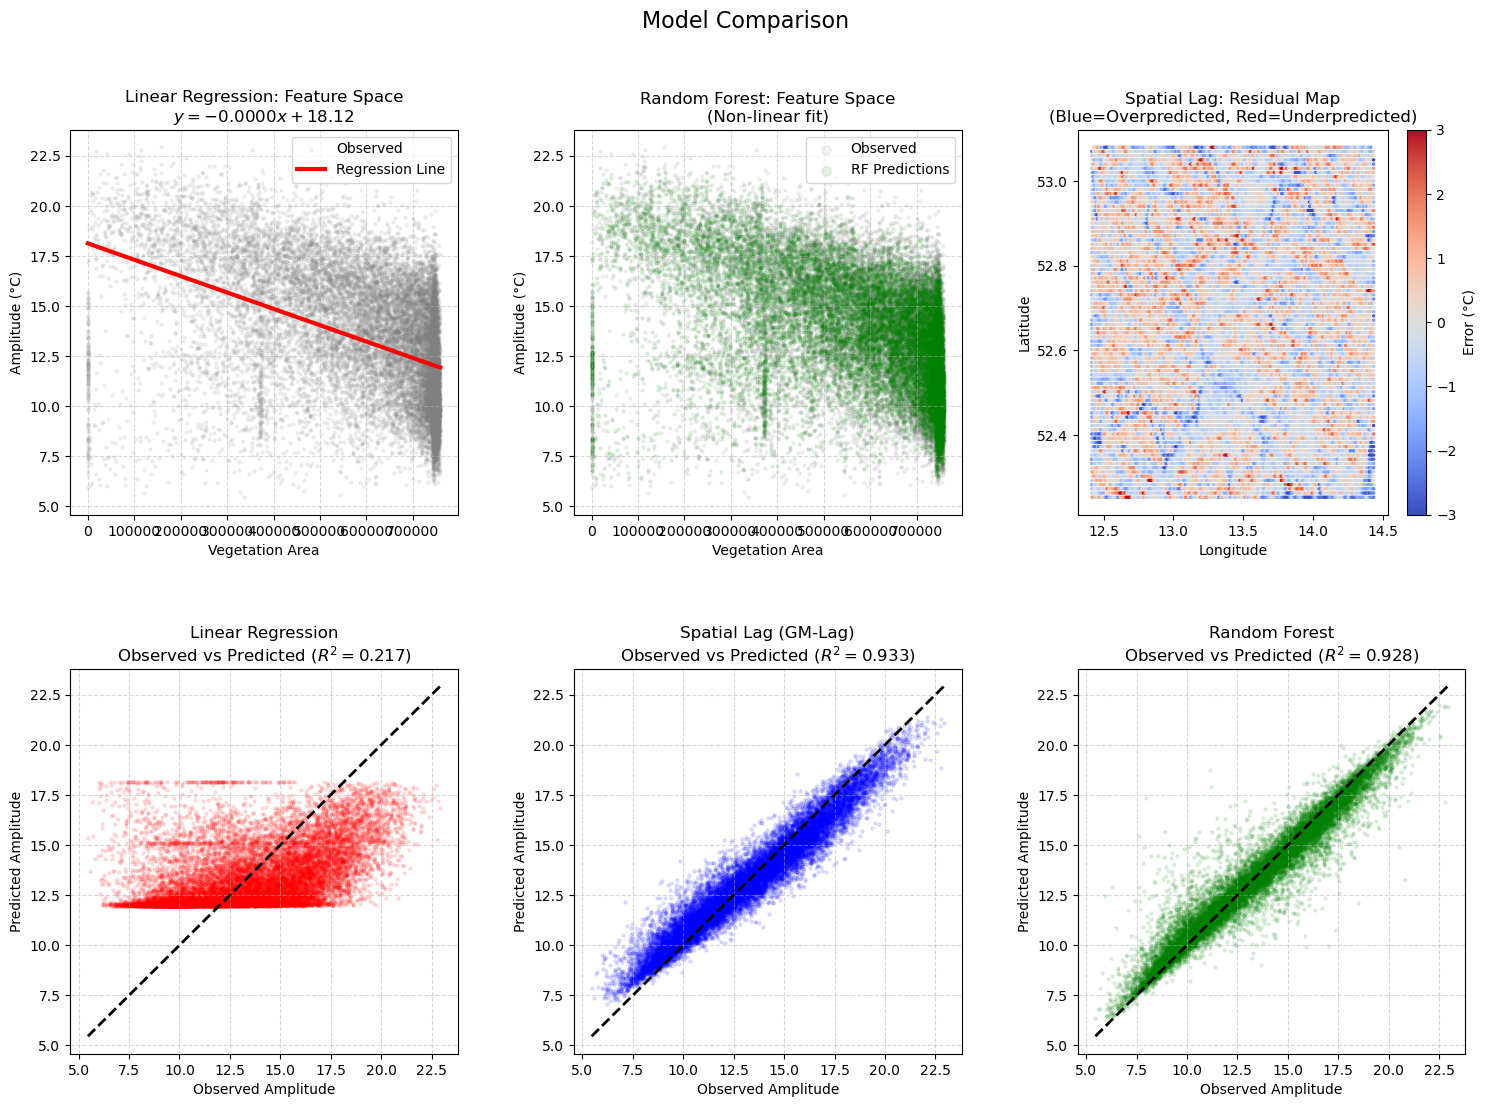

In [4]:
print("Step 1: Loading Data...")
file_path = "data/berlin_final_data.csv"
df = pd.read_csv(file_path)

df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

target = 'amplitude'
features = ['ndvi_area']

gdf = gdf.dropna(subset=[target] + features)
gdf = gdf[gdf[target] > 0]

y = gdf[target].values.reshape(-1, 1)
X = gdf[features].values
print(f"Data ready: {len(gdf)} samples.")

print("Step 2: Training Models...")
ols = OLS(y, X, name_y=target, name_x=features)
ols_pred = ols.predy.flatten()
intercept = ols.betas[0][0]
slope = ols.betas[1][0]

w = libpysal.weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r'
gm_lag = GM_Lag(y, X, w=w, w_lags=1, name_y=target, name_x=features)
lag_pred = gm_lag.predy.flatten()

X_rf = gdf[features + ['lat', 'lon']].values
y_rf = gdf[target].values
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_full = rf.predict(X_rf)
rf_r2 = r2_score(y_rf, rf_pred_full)

print("\n--- Model Comparison Table ---")
results = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Spatial Lag (GM-Lag)', 'Random Forest'],
    'R-Squared': [ols.r2, gm_lag.pr2, rf_r2],
    'RMSE': [
        np.sqrt(mean_squared_error(y, ols_pred)),
        np.sqrt(mean_squared_error(y, lag_pred)),
        np.sqrt(mean_squared_error(y, rf_pred_full))
    ]
})
print(results)

print("\nStep 4: Visualizing Results...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1 = plt.subplot(2, 3, 1)
ax1.scatter(gdf['ndvi_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
x_vals = np.linspace(gdf['ndvi_area'].min(), gdf['ndvi_area'].max(), 100)
y_vals = intercept + slope * x_vals
ax1.plot(x_vals, y_vals, color='red', linewidth=3, label='Regression Line')
ax1.set_title(f'Linear Regression: Feature Space\n$y={slope:.4f}x + {intercept:.2f}$', fontsize=12)
ax1.set_xlabel('Vegetation Area')
ax1.set_ylabel('Amplitude (°C)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = plt.subplot(2, 3, 2)
ax2.scatter(gdf['ndvi_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
ax2.scatter(gdf['ndvi_area'], rf_pred_full, alpha=0.1, s=5, color='green', label='RF Predictions')
ax2.set_title(f'Random Forest: Feature Space\n(Non-linear fit)', fontsize=12)
ax2.set_xlabel('Vegetation Area')
ax2.set_ylabel('Amplitude (°C)')
ax2.legend(markerscale=3)
ax2.grid(True, linestyle='--', alpha=0.5)

ax3 = plt.subplot(2, 3, 3)
residuals = y.flatten() - lag_pred
sc = ax3.scatter(gdf['lon'], gdf['lat'], c=residuals, cmap='coolwarm', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax3, label='Error (°C)')
ax3.set_title('Spatial Lag: Residual Map\n(Blue=Overpredicted, Red=Underpredicted)', fontsize=12)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

def plot_obs_vs_pred(ax, y_true, y_pred, title, r2, color):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    ax.set_title(f'{title}\nObserved vs Predicted ($R^2={r2:.3f}$)', fontsize=12)
    ax.set_xlabel('Observed Amplitude')
    ax.set_ylabel('Predicted Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

ax4 = plt.subplot(2, 3, 4)
plot_obs_vs_pred(ax4, y.flatten(), ols_pred, "Linear Regression", ols.r2, 'red')

ax5 = plt.subplot(2, 3, 5)
plot_obs_vs_pred(ax5, y.flatten(), lag_pred, "Spatial Lag (GM-Lag)", gm_lag.pr2, 'blue')

ax6 = plt.subplot(2, 3, 6)
plot_obs_vs_pred(ax6, y.flatten(), rf_pred_full, "Random Forest", rf_r2, 'green')

plt.suptitle('Model Comparison', fontsize=16)
plt.savefig('illustrations/model_comparison_full_ndvi_Berlin.png', dpi=300)
plt.show()

3. Dependency between built-up area and LST amplitude in Paris

Step 1: Loading Data...
Data ready: 12231 samples.
Step 2: Training Models...

--- Model Comparison Table ---
                     Model  R-Squared      RMSE
0  Linear Regression (OLS)   0.010988  2.401832
1     Spatial Lag (GM-Lag)   0.933550  0.716666
2            Random Forest   0.953855  0.518804

Step 4: Visualizing Results...


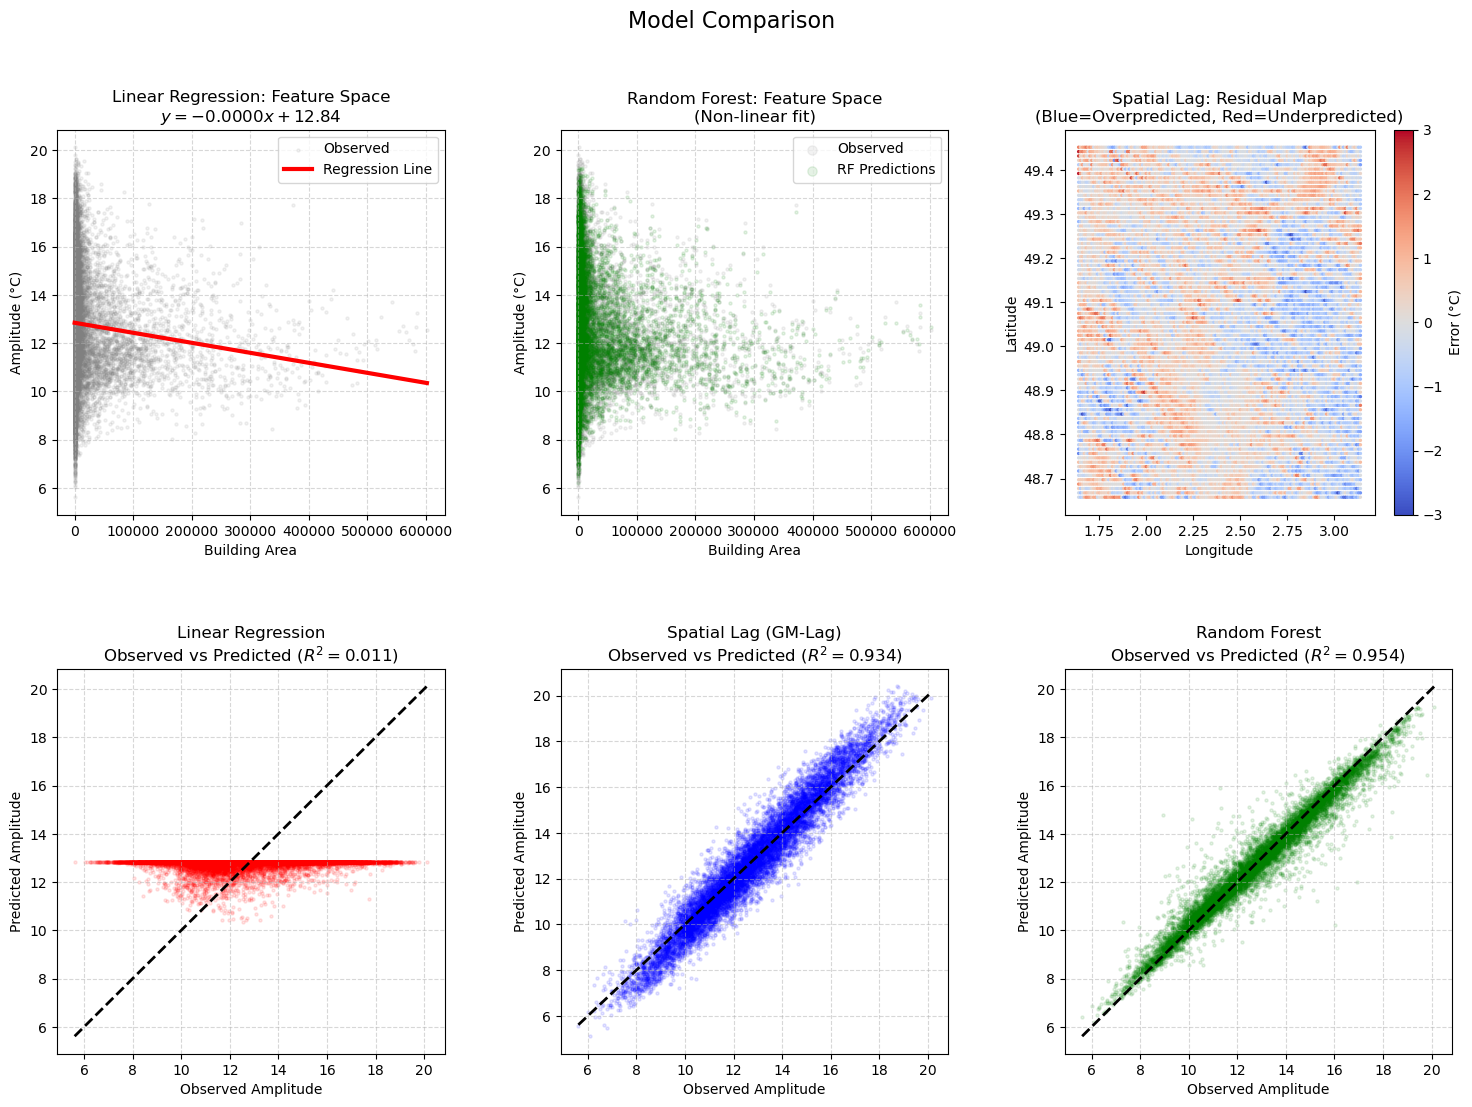

In [5]:
print("Step 1: Loading Data...")
file_path = "data/paris_final_data.csv"
df = pd.read_csv(file_path)

df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

target = 'amplitude'
features = ['building_area']

gdf = gdf.dropna(subset=[target] + features)
gdf = gdf[gdf[target] > 0]

y = gdf[target].values.reshape(-1, 1)
X = gdf[features].values
print(f"Data ready: {len(gdf)} samples.")

print("Step 2: Training Models...")
ols = OLS(y, X, name_y=target, name_x=features)
ols_pred = ols.predy.flatten()
intercept = ols.betas[0][0]
slope = ols.betas[1][0]

w = libpysal.weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r'
gm_lag = GM_Lag(y, X, w=w, w_lags=1, name_y=target, name_x=features)
lag_pred = gm_lag.predy.flatten()

X_rf = gdf[features + ['lat', 'lon']].values
y_rf = gdf[target].values
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_full = rf.predict(X_rf)
rf_r2 = r2_score(y_rf, rf_pred_full)

print("\n--- Model Comparison Table ---")
results = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Spatial Lag (GM-Lag)', 'Random Forest'],
    'R-Squared': [ols.r2, gm_lag.pr2, rf_r2],
    'RMSE': [
        np.sqrt(mean_squared_error(y, ols_pred)),
        np.sqrt(mean_squared_error(y, lag_pred)),
        np.sqrt(mean_squared_error(y, rf_pred_full))
    ]
})
print(results)

print("\nStep 4: Visualizing Results...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1 = plt.subplot(2, 3, 1)
ax1.scatter(gdf['building_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
x_vals = np.linspace(gdf['building_area'].min(), gdf['building_area'].max(), 100)
y_vals = intercept + slope * x_vals
ax1.plot(x_vals, y_vals, color='red', linewidth=3, label='Regression Line')
ax1.set_title(f'Linear Regression: Feature Space\n$y={slope:.4f}x + {intercept:.2f}$', fontsize=12)
ax1.set_xlabel('Building Area')
ax1.set_ylabel('Amplitude (°C)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = plt.subplot(2, 3, 2)
ax2.scatter(gdf['building_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
ax2.scatter(gdf['building_area'], rf_pred_full, alpha=0.1, s=5, color='green', label='RF Predictions')
ax2.set_title(f'Random Forest: Feature Space\n(Non-linear fit)', fontsize=12)
ax2.set_xlabel('Building Area')
ax2.set_ylabel('Amplitude (°C)')
ax2.legend(markerscale=3)
ax2.grid(True, linestyle='--', alpha=0.5)

ax3 = plt.subplot(2, 3, 3)
residuals = y.flatten() - lag_pred
sc = ax3.scatter(gdf['lon'], gdf['lat'], c=residuals, cmap='coolwarm', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax3, label='Error (°C)')
ax3.set_title('Spatial Lag: Residual Map\n(Blue=Overpredicted, Red=Underpredicted)', fontsize=12)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

def plot_obs_vs_pred(ax, y_true, y_pred, title, r2, color):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    ax.set_title(f'{title}\nObserved vs Predicted ($R^2={r2:.3f}$)', fontsize=12)
    ax.set_xlabel('Observed Amplitude')
    ax.set_ylabel('Predicted Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

ax4 = plt.subplot(2, 3, 4)
plot_obs_vs_pred(ax4, y.flatten(), ols_pred, "Linear Regression", ols.r2, 'red')

ax5 = plt.subplot(2, 3, 5)
plot_obs_vs_pred(ax5, y.flatten(), lag_pred, "Spatial Lag (GM-Lag)", gm_lag.pr2, 'blue')

ax6 = plt.subplot(2, 3, 6)
plot_obs_vs_pred(ax6, y.flatten(), rf_pred_full, "Random Forest", rf_r2, 'green')

plt.suptitle('Model Comparison', fontsize=16)
plt.savefig('illustrations/model_comparison_full_built_Paris.png', dpi=300)
plt.show()

3. Dependency between vegetation area and LST amplitude in Paris

Step 1: Loading Data...
Data ready: 12231 samples.
Step 2: Training Models...

--- Model Comparison Table ---
                     Model  R-Squared      RMSE
0  Linear Regression (OLS)   0.248116  2.094195
1     Spatial Lag (GM-Lag)   0.935835  0.674287
2            Random Forest   0.947291  0.554479

Step 4: Visualizing Results...


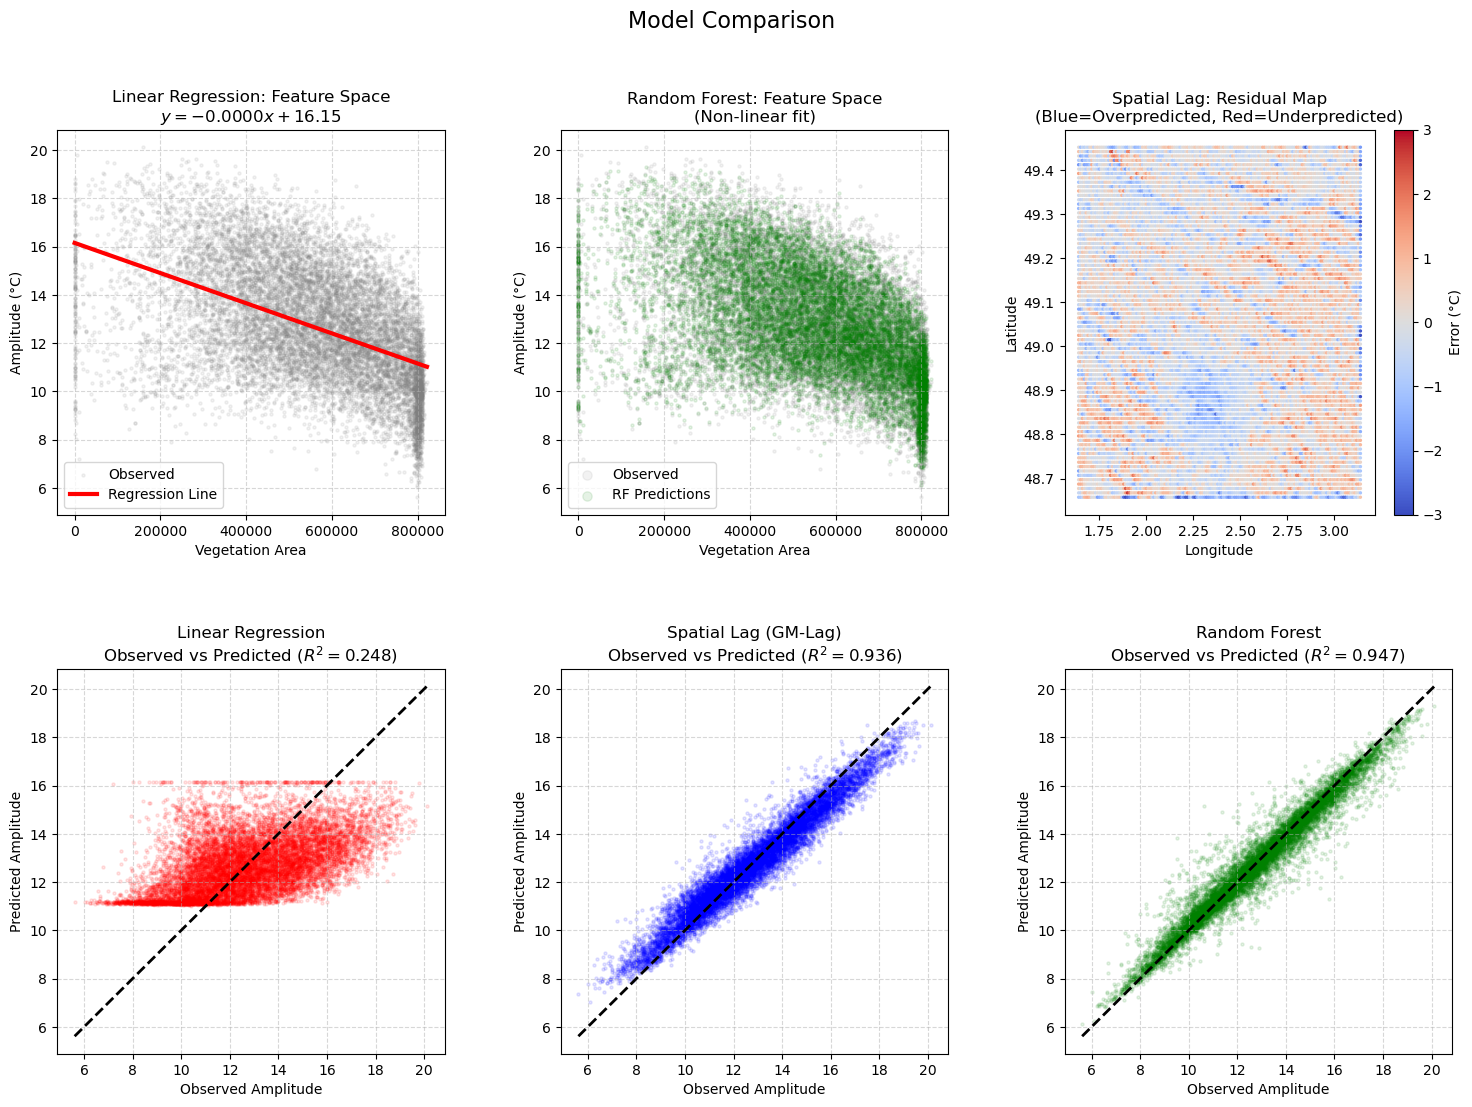

In [6]:
print("Step 1: Loading Data...")
file_path = "data/paris_final_data.csv"
df = pd.read_csv(file_path)

df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

target = 'amplitude'
features = ['ndvi_area']

gdf = gdf.dropna(subset=[target] + features)
gdf = gdf[gdf[target] > 0]

y = gdf[target].values.reshape(-1, 1)
X = gdf[features].values
print(f"Data ready: {len(gdf)} samples.")

print("Step 2: Training Models...")
ols = OLS(y, X, name_y=target, name_x=features)
ols_pred = ols.predy.flatten()
intercept = ols.betas[0][0]
slope = ols.betas[1][0]

w = libpysal.weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r'
gm_lag = GM_Lag(y, X, w=w, w_lags=1, name_y=target, name_x=features)
lag_pred = gm_lag.predy.flatten()

X_rf = gdf[features + ['lat', 'lon']].values
y_rf = gdf[target].values
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_full = rf.predict(X_rf)
rf_r2 = r2_score(y_rf, rf_pred_full)

print("\n--- Model Comparison Table ---")
results = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Spatial Lag (GM-Lag)', 'Random Forest'],
    'R-Squared': [ols.r2, gm_lag.pr2, rf_r2],
    'RMSE': [
        np.sqrt(mean_squared_error(y, ols_pred)),
        np.sqrt(mean_squared_error(y, lag_pred)),
        np.sqrt(mean_squared_error(y, rf_pred_full))
    ]
})
print(results)

print("\nStep 4: Visualizing Results...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1 = plt.subplot(2, 3, 1)
ax1.scatter(gdf['ndvi_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
x_vals = np.linspace(gdf['ndvi_area'].min(), gdf['ndvi_area'].max(), 100)
y_vals = intercept + slope * x_vals
ax1.plot(x_vals, y_vals, color='red', linewidth=3, label='Regression Line')
ax1.set_title(f'Linear Regression: Feature Space\n$y={slope:.4f}x + {intercept:.2f}$', fontsize=12)
ax1.set_xlabel('Vegetation Area')
ax1.set_ylabel('Amplitude (°C)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = plt.subplot(2, 3, 2)
ax2.scatter(gdf['ndvi_area'], gdf['amplitude'], alpha=0.1, s=5, color='gray', label='Observed')
ax2.scatter(gdf['ndvi_area'], rf_pred_full, alpha=0.1, s=5, color='green', label='RF Predictions')
ax2.set_title(f'Random Forest: Feature Space\n(Non-linear fit)', fontsize=12)
ax2.set_xlabel('Vegetation Area')
ax2.set_ylabel('Amplitude (°C)')
ax2.legend(markerscale=3)
ax2.grid(True, linestyle='--', alpha=0.5)

ax3 = plt.subplot(2, 3, 3)
residuals = y.flatten() - lag_pred
sc = ax3.scatter(gdf['lon'], gdf['lat'], c=residuals, cmap='coolwarm', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax3, label='Error (°C)')
ax3.set_title('Spatial Lag: Residual Map\n(Blue=Overpredicted, Red=Underpredicted)', fontsize=12)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

def plot_obs_vs_pred(ax, y_true, y_pred, title, r2, color):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    ax.set_title(f'{title}\nObserved vs Predicted ($R^2={r2:.3f}$)', fontsize=12)
    ax.set_xlabel('Observed Amplitude')
    ax.set_ylabel('Predicted Amplitude')
    ax.grid(True, linestyle='--', alpha=0.5)

ax4 = plt.subplot(2, 3, 4)
plot_obs_vs_pred(ax4, y.flatten(), ols_pred, "Linear Regression", ols.r2, 'red')

ax5 = plt.subplot(2, 3, 5)
plot_obs_vs_pred(ax5, y.flatten(), lag_pred, "Spatial Lag (GM-Lag)", gm_lag.pr2, 'blue')

ax6 = plt.subplot(2, 3, 6)
plot_obs_vs_pred(ax6, y.flatten(), rf_pred_full, "Random Forest", rf_r2, 'green')

plt.suptitle('Model Comparison', fontsize=16)
plt.savefig('illustrations/model_comparison_full_ndvi_Paris.png', dpi=300)
plt.show()

creating graphs comparing the temperatures between urban and suburban areas

Graph saved: illustrations/Paris_analysis.png


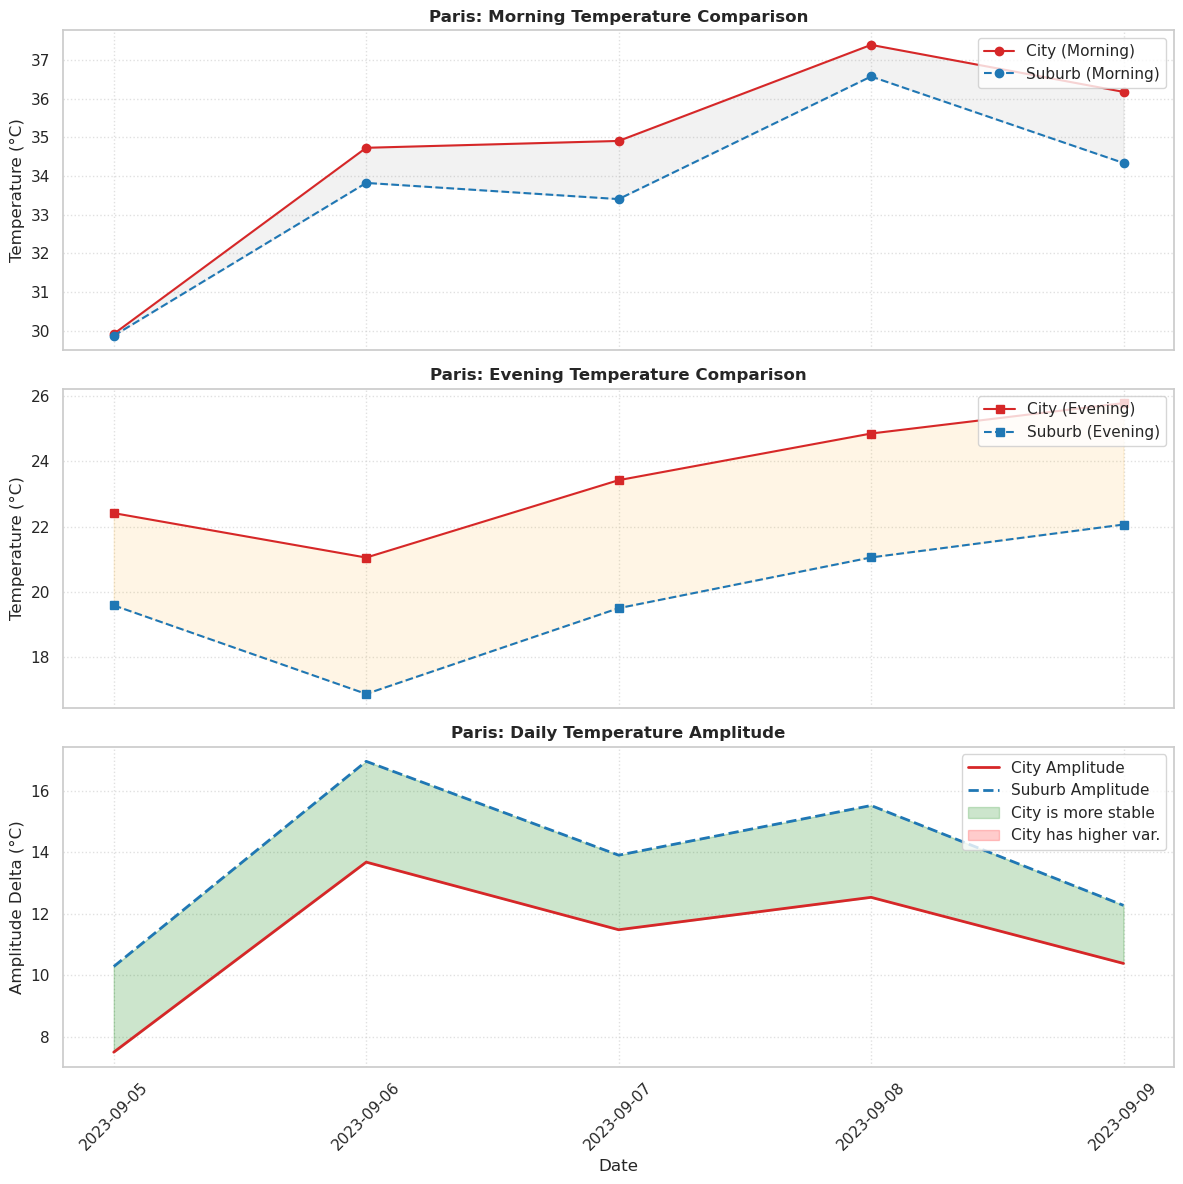

Graph saved: illustrations/Berlin_analysis.png


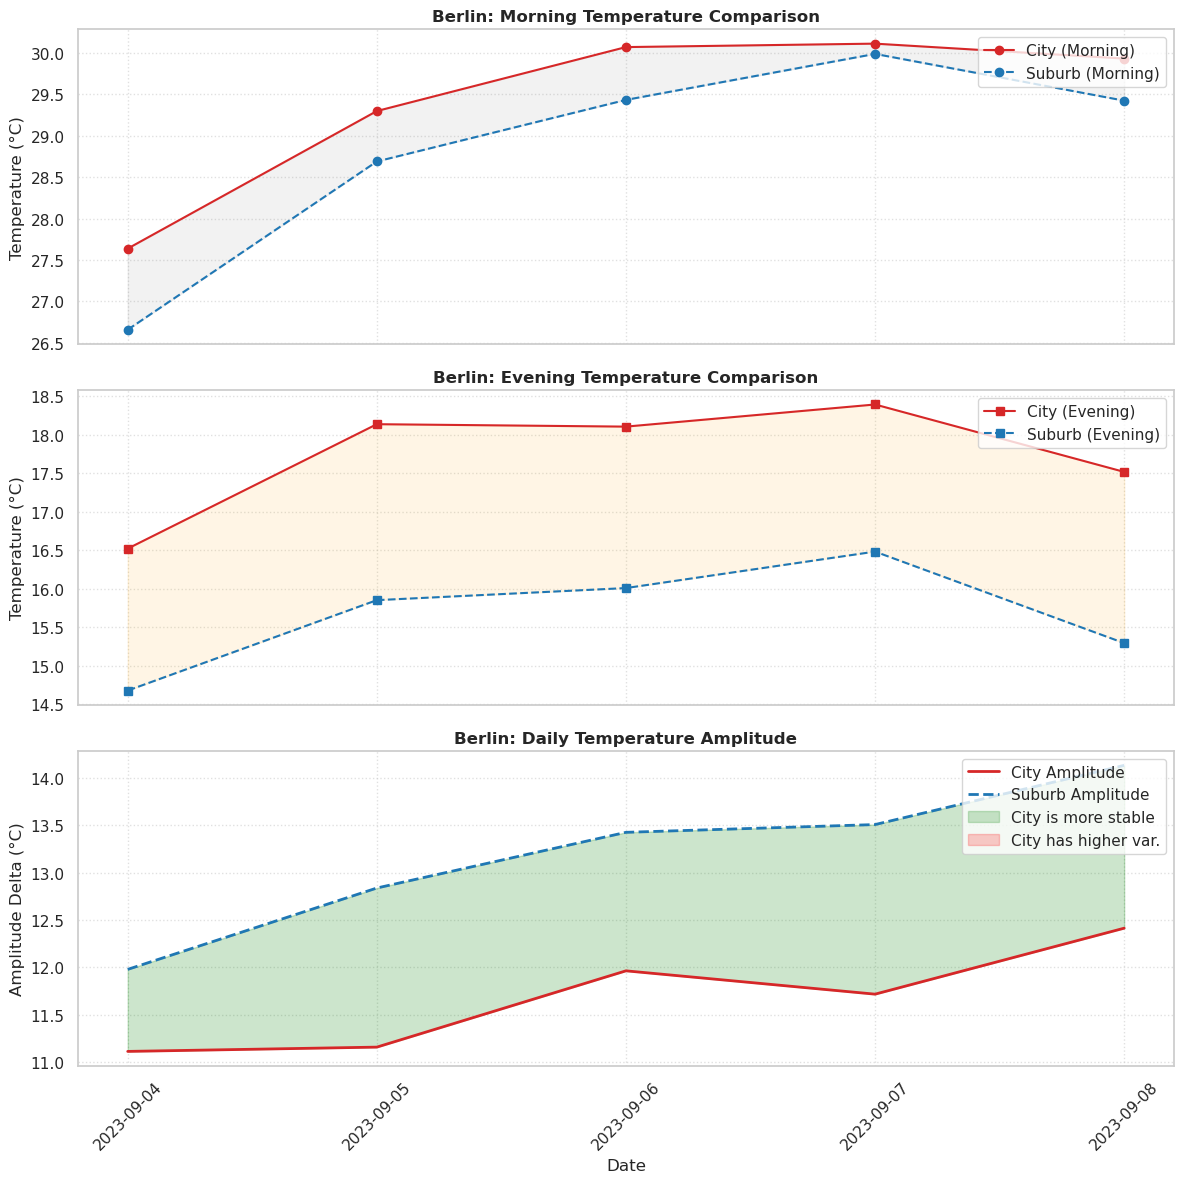

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

city_files = {
    "Paris": "results/amplitudes_Paris.csv",
    "Berlin": "results/amplitudes_Berlin.csv"
}

def plot_city_analysis(city_name, file_path):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File for {city_name} not found.")
        return

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    color_city = '#d62728'   
    color_suburb = '#1f77b4' 
    
    # Morning Temperatures
    ax0 = axes[0]
    ax0.plot(df['date'], df['t_morn_city'], marker='o', linestyle='-', color=color_city, label='City (Morning)')
    ax0.plot(df['date'], df['t_morn_suburb'], marker='o', linestyle='--', color=color_suburb, label='Suburb (Morning)')
    
    ax0.fill_between(df['date'], df['t_morn_city'], df['t_morn_suburb'], alpha=0.1, color='gray')
    
    ax0.set_title(f"{city_name}: Morning Temperature Comparison", fontweight='bold')
    ax0.set_ylabel("Temperature (°C)")
    ax0.legend(loc='upper right')
    ax0.grid(True, linestyle=':', alpha=0.6)

    #Evening Temperatures
    ax1 = axes[1]
    ax1.plot(df['date'], df['t_even_city'], marker='s', linestyle='-', color=color_city, label='City (Evening)')
    ax1.plot(df['date'], df['t_even_suburb'], marker='s', linestyle='--', color=color_suburb, label='Suburb (Evening)')
    
    ax1.fill_between(df['date'], df['t_even_city'], df['t_even_suburb'], alpha=0.1, color='orange')

    ax1.set_title(f"{city_name}: Evening Temperature Comparison", fontweight='bold')
    ax1.set_ylabel("Temperature (°C)")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Daily Amplitude
    ax2 = axes[2]
    
    width = 0.35 
    ax2.plot(df['date'], df['amp_city'], color=color_city, linewidth=2, label='City Amplitude')
    ax2.plot(df['date'], df['amp_suburb'], color=color_suburb, linewidth=2, linestyle='--', label='Suburb Amplitude')
    
    ax2.fill_between(df['date'], df['amp_city'], df['amp_suburb'], 
                     where=(df['amp_city'] < df['amp_suburb']),
                     interpolate=True, color='green', alpha=0.2, label='City is more stable')
    
    ax2.fill_between(df['date'], df['amp_city'], df['amp_suburb'], 
                     where=(df['amp_city'] >= df['amp_suburb']),
                     interpolate=True, color='red', alpha=0.2, label='City has higher var.')

    ax2.set_title(f"{city_name}: Daily Temperature Amplitude", fontweight='bold')
    ax2.set_ylabel("Amplitude Delta (°C)")
    ax2.set_xlabel("Date")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.xticks(rotation=45)

    plt.tight_layout()
    
    filename = f"illustrations/{city_name}_analysis.png"
    plt.savefig(filename, dpi=150)
    print(f"Graph saved: {filename}")
    plt.show()

for city, file_path in city_files.items():
    plot_city_analysis(city, file_path)